# Gate 1 — Selected Families Across Practical SNR Levels

This notebook filters the existing dense-SNR dataset created by `D_S1_scatterplot_generation.ipynb`.

- Signal set: 14 families × 11 SNR levels × 5 independent replicates for every enabled variant level
- Three switches independently control Mild, Standard, and Strong; the default enables Standard + Strong, producing 1,540 signal plots.
- Columns: nominal SNR = 10, 5, 4, 3, 2, 1, 0.5, 0.4, 0.3, 0.2, 0.1
- The closest SNR already present in the dense grid is used and reported explicitly.
- Null contributes 100 independent random realizations (20 batches × 5 replicates) because SNR is not meaningful when there is no signal.
- With the default switches, the unified candidate set contains 1,500 plots (1,400 signal + 100 Null) and does not assign human labels.


In [4]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
try:
    from minepy import MINE
except ImportError:
    MINE = None

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)

# Locate the repository root whether launched from the root, D/, or D/Global/.
cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
project_root = next(
    (root for root in search_roots if (root / 'D' / 'output' / 'S1' / 'cases.csv').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        'Could not locate the repository root containing D/output/S1/cases.csv.'
    )

data_dir = project_root / 'D' / 'output' / 'S1'
output_dir = project_root / 'D' / 'Global' / 'output' / 'S1_gate1_preview'
output_dir.mkdir(parents=True, exist_ok=True)

cases_path = data_dir / 'cases.csv'
points_path = data_dir / 'scatter_points.npz'
metrics_path = project_root / 'D' / 'output' / 'S2' / 'metrics_full.parquet'

assert cases_path.exists(), cases_path
assert points_path.exists(), points_path
assert metrics_path.exists(), metrics_path

def compute_mic(x_values, y_values):
    if MINE is None:
        return np.nan
    mine = MINE(alpha=0.6, c=15)
    mine.compute_score(np.asarray(x_values, dtype=float), np.asarray(y_values, dtype=float))
    return float(mine.mic())

def annotate_mic(ax, mic_value, fontsize=7):
    text = 'MIC = n/a' if not np.isfinite(mic_value) else f'MIC = {float(mic_value):.3f}'
    ax.text(
        0.97, 0.95, text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=fontsize, fontweight='bold', color='#222222',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.4),
        zorder=10,
    )

print(f'Cases:  {cases_path}')
print(f'Points: {points_path}')
print(f'Metrics: {metrics_path}')
print(f'Output: {output_dir}')


Cases:  /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/output/S1/cases.csv
Points: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/output/S1/scatter_points.npz
Metrics: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/output/S2/metrics_full.parquet
Output: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview


## Selection design

The function parameters, direction, x distribution, noise distribution, spread pattern, and sample size remain fixed. Only SNR changes. Existing replicates 0–4 are retained as five distinct realizations, and every realization must receive its own human label.


In [5]:
selected_families = [
    ('F01', 'Linear'),
    ('F03', 'Power convex'),
    ('F05', 'Power concave'),
    ('F07', 'Saturation'),
    ('F13', 'S-curve'),
    ('F15', 'Threshold'),
    ('F18', 'U-shape'),
    ('F21', 'Cubic'),
    ('F19', 'Spike'),
    ('F23', 'Two Lines'),
    ('F24', 'Line + Parabola'),
    ('F25', 'Multi-regime'),
    ('F26', 'Windowed J'),
    ('F22', 'Oscillation'),
]

nominal_snr = np.array([10.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.5, 0.4, 0.3, 0.2, 0.1])

# Optional family-specific extra SNR levels beyond the shared grid.
# SNR 4 is now part of the shared grid for every family, so no supplement is needed.
supplemental_snr_by_family = {}
supplemental_variant_levels_requested = set()

# Variant-level switches. Null is included once and is independent of these switches.
include_mild = False
include_standard = True
include_strong = True

variant_level_switches = {
    'mild': include_mild,
    'standard': include_standard,
    'strong': include_strong,
}
selected_variant_levels = [
    level for level, enabled in variant_level_switches.items() if enabled
]
if not selected_variant_levels:
    raise ValueError('Enable at least one of include_mild, include_standard, or include_strong.')

selected_replicates = list(range(5))

# Step-1 labels copied from D_S3_fuzzy_calibration.ipynb.
calibration_clear_snr = {
    'F01': 3.0, 'F03': 2.0, 'F05': 2.0, 'F13': 5.0,
    'F15': 5.0, 'F18': 1.0, 'F21': 3.0, 'F22': 3.0,
    'F23': 8.0, 'F24': 8.0, 'F25': 8.0, 'F26': 8.0,
}
calibration_threshold_snr = {
    'F01': 0.3, 'F03': 0.3, 'F05': 0.3, 'F13': 1.0,
    'F15': 0.5, 'F18': 0.3, 'F21': 0.3, 'F22': 0.3,
    'F23': 3.0, 'F24': 3.0, 'F25': 1.0, 'F26': 1.0,
}
calibration_no_global = {'F07', 'F19'}

# Manual nominal-SNR overrides from the latest visual review.
manual_label_overrides = {
    'F01': {3.0: 1.0, 2.0: 1.0, 1.0: 1.0, 0.5: 0.5, 0.4: 0.5},
    'F03': {2.0: 1.0, 1.0: 1.0, 0.5: 0.5, 0.4: 0.5},
    'F05': {2.0: 1.0, 1.0: 1.0, 0.5: 0.5, 0.4: 0.5},
    'F13': {5.0: 1.0},
    'F15': {5.0: 1.0, 4.0: 1.0, 3.0: 1.0},
    'F18': {0.5: 1.0, 0.4: 1.0, 0.3: 0.5},
    'F21': {3.0: 1.0, 2.0: 1.0},
    'F23': {5.0: 1.0, 4.0: 1.0, 3.0: 0.5},
    'F24': {5.0: 1.0, 4.0: 1.0, 3.0: 0.5},
    'F25': {5.0: 1.0, 4.0: 1.0, 3.0: 1.0, 2.0: 1.0, 0.5: 0.5},
    'F26': {5.0: 1.0, 4.0: 1.0, 3.0: 1.0, 2.0: 1.0, 0.5: 0.5},
    'F22': {3.0: 1.0, 2.0: 1.0, 1.0: 1.0, 0.5: 1.0,
            0.4: 0.5, 0.3: 0.5, 0.2: 0.5},
}
label_source_name = 'D_S3_fuzzy_calibration Step 1 + manual nominal-SNR overrides'

def calibration_label_for_case(family_id, actual_snr_value, nominal_snr_value=None):
    if family_id == 'Null' or family_id in calibration_no_global:
        return 0.0
    if family_id in manual_label_overrides and nominal_snr_value is not None:
        for target_snr, override_label in manual_label_overrides[family_id].items():
            if np.isclose(float(nominal_snr_value), target_snr, rtol=0.0, atol=1e-12):
                return float(override_label)
    if float(actual_snr_value) >= calibration_clear_snr[family_id]:
        return 1.0
    if float(actual_snr_value) <= calibration_threshold_snr[family_id]:
        return 0.0
    return 0.5

label_styles = {
    0.0: {'edge': '#D32F2F', 'face': '#FFF0F0', 'legend': '0 = No / unrecognizable'},
    0.5: {'edge': '#E65100', 'face': '#FFF8E1', 'legend': '0.5 = Uncertain'},
    1.0: {'edge': '#2E7D32', 'face': '#F0FFF0', 'legend': '1 = Yes / clear'},
}
label_legend_handles = [
    Patch(facecolor=label_styles[value]['face'], edgecolor=label_styles[value]['edge'],
          linewidth=2.0, label=label_styles[value]['legend'])
    for value in [0.0, 0.5, 1.0]
]

cases = pd.read_csv(cases_path, low_memory=False)
cases['snr_float'] = pd.to_numeric(cases['snr'], errors='coerce')
metrics = pd.read_parquet(metrics_path, columns=['case_id', 'MIC'])
metrics['case_id'] = pd.to_numeric(metrics['case_id'], errors='raise').astype(int)
if not metrics['case_id'].is_unique:
    raise ValueError('Expected case_id to be unique in metrics_full.parquet.')
mic_by_case_id = metrics.set_index('case_id')['MIC']

available_snr = np.sort(cases.loc[np.isfinite(cases['snr_float']), 'snr_float'].unique())
actual_snr = np.array([
    available_snr[np.argmin(np.abs(available_snr - target))]
    for target in nominal_snr
])

snr_mapping = pd.DataFrame({
    'nominal_snr': nominal_snr,
    'actual_snr': actual_snr,
    'relative_error_percent': 100.0 * (actual_snr - nominal_snr) / nominal_snr,
    'signal_variance_fraction': actual_snr / (1.0 + actual_snr),
})

display(snr_mapping.round({
    'actual_snr': 7,
    'relative_error_percent': 3,
    'signal_variance_fraction': 3,
}))


,nominal_snr,actual_snr,relative_error_percent,signal_variance_fraction
0,10.0,10.217053,2.171,0.911
1,5.0,4.946605,-1.068,0.832
2,4.0,4.058757,1.469,0.802
3,3.0,2.918790,-2.707,0.745
4,2.0,1.965055,-1.747,0.663
5,1.0,1.016235,1.624,0.504
6,0.5,0.492012,-1.598,0.330
7,0.4,0.403703,0.926,0.288
8,0.3,0.290316,-3.228,0.225
9,0.2,0.195453,-2.273,0.163


In [6]:
selection_rows = []

def nearest_available_snr(target):
    return float(available_snr[np.argmin(np.abs(available_snr - float(target)))])

def append_selected_case(family_cases, family_id, short_name, variant_level,
                         nominal, actual, replicate, is_supplemental):
    match = family_cases[
        np.isclose(family_cases['snr_float'], actual, rtol=0.0, atol=1e-12)
        & family_cases['replicate'].eq(replicate)
    ]
    if len(match) != 1:
        raise ValueError(
            f'Expected one case for {family_id}, level={variant_level}, '
            f'SNR={actual}, rep={replicate}; found {len(match)}'
        )
    row = match.iloc[0]
    selection_rows.append({
        'plot_id': f'{family_id}_{variant_level}_snr_{nominal:g}_rep_{replicate + 1}',
        'family_id': family_id,
        'family_short_name': short_name,
        'family_name': row['family_name'],
        'variant_name': row['variant_name'],
        'variant_level': row['variant_level'],
        'nominal_snr': float(nominal),
        'actual_snr': float(actual),
        'replicate': int(row['replicate']),
        'null_batch': np.nan,
        'case_id': int(row['case_id']),
        'array_index': int(row['case_id']) - 1,
        'is_supplemental': bool(is_supplemental),
        'review_status': 'pending_manual_review' if is_supplemental else 'labeled',
    })

for variant_level in selected_variant_levels:
    for family_id, short_name in selected_families:
        family_cases = cases[
            cases['family_id'].eq(family_id)
            & cases['variant_level'].eq(variant_level)
            & cases['replicate'].isin(selected_replicates)
        ].copy()

        config_ids = family_cases['shape_config_id'].unique()
        if len(config_ids) != 1:
            raise ValueError(
                f'Expected one {variant_level!r} config for {family_id}, found {config_ids.tolist()}'
            )

        for nominal, actual in zip(nominal_snr, actual_snr):
            for replicate in selected_replicates:
                append_selected_case(
                    family_cases, family_id, short_name, variant_level,
                    nominal, actual, replicate, is_supplemental=False,
                )

        if (
            family_id in supplemental_snr_by_family
            and variant_level in supplemental_variant_levels_requested
        ):
            for supplemental_nominal in supplemental_snr_by_family[family_id]:
                supplemental_actual = nearest_available_snr(supplemental_nominal)
                for replicate in selected_replicates:
                    append_selected_case(
                        family_cases, family_id, short_name, variant_level,
                        supplemental_nominal, supplemental_actual, replicate,
                        is_supplemental=True,
                    )

selection = pd.DataFrame(selection_rows)
selection['MIC'] = selection['case_id'].map(mic_by_case_id)
if selection['MIC'].isna().any():
    missing_case_ids = selection.loc[selection['MIC'].isna(), 'case_id'].tolist()[:10]
    raise ValueError(f'Missing MIC values for selected case IDs: {missing_case_ids}')
selection['label'] = [
    np.nan if is_supplemental else calibration_label_for_case(
        family_id, actual_snr_value, nominal_snr_value
    )
    for family_id, actual_snr_value, nominal_snr_value, is_supplemental in zip(
        selection['family_id'], selection['actual_snr'], selection['nominal_snr'],
        selection['is_supplemental'],
    )
]
selection['label_source'] = np.where(
    selection['is_supplemental'],
    'pending manual review: focused F23/F24 SNR 4 boundary check',
    label_source_name,
)
expected_base_signal_count = (
    len(selected_families)
    * len(selected_variant_levels)
    * len(nominal_snr)
    * len(selected_replicates)
)
expected_supplemental_count = sum(
    len(snr_values) * len(selected_replicates)
    for family_id, snr_values in supplemental_snr_by_family.items()
    for variant_level in selected_variant_levels
    if variant_level in supplemental_variant_levels_requested
)
expected_signal_count = expected_base_signal_count + expected_supplemental_count
assert len(selection) == expected_signal_count
selection['loaded_position'] = np.arange(len(selection), dtype=int)

print(f'Selected signal plots: {len(selection)}')
print(f'  Enabled variant levels: {selected_variant_levels}')
print(
    f'  Base: {len(selected_families)} families × {len(selected_variant_levels)} levels × '
    f'{len(nominal_snr)} SNR × {len(selected_replicates)} replicates '
    f'= {expected_base_signal_count}'
)
if expected_supplemental_count:
    print(f'  Additional family-specific SNR plots: {expected_supplemental_count}')
display(selection.head(12))


Selected signal plots: 1540
  Enabled variant levels: ['standard', 'strong']
  Base: 14 families × 2 levels × 11 SNR × 5 replicates = 1540


,plot_id,family_id,family_short_name,family_name,variant_name,variant_level,nominal_snr,actual_snr,replicate,null_batch,case_id,array_index,is_supplemental,review_status,MIC,label,label_source,loaded_position
0,F01_standard_snr_10_rep_1,F01,Linear,Linear positive,slope_1,standard,10.0,10.217053,0,NaN,3461,3460,False,labeled,0.876648,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,0
1,F01_standard_snr_10_rep_2,F01,Linear,Linear positive,slope_1,standard,10.0,10.217053,1,NaN,3462,3461,False,labeled,0.882697,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,1
2,F01_standard_snr_10_rep_3,F01,Linear,Linear positive,slope_1,standard,10.0,10.217053,2,NaN,3463,3462,False,labeled,0.925003,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,2
3,F01_standard_snr_10_rep_4,F01,Linear,Linear positive,slope_1,standard,10.0,10.217053,3,NaN,3464,3463,False,labeled,0.871660,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,3
4,F01_standard_snr_10_rep_5,F01,Linear,Linear positive,slope_1,standard,10.0,10.217053,4,NaN,3465,3464,False,labeled,0.925034,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,4
5,F01_standard_snr_5_rep_1,F01,Linear,Linear positive,slope_1,standard,5.0,4.946605,0,NaN,3351,3350,False,labeled,0.816907,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,5
6,F01_standard_snr_5_rep_2,F01,Linear,Linear positive,slope_1,standard,5.0,4.946605,1,NaN,3352,3351,False,labeled,0.795322,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,6
7,F01_standard_snr_5_rep_3,F01,Linear,Linear positive,slope_1,standard,5.0,4.946605,2,NaN,3353,3352,False,labeled,0.815372,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,7
8,F01_standard_snr_5_rep_4,F01,Linear,Linear positive,slope_1,standard,5.0,4.946605,3,NaN,3354,3353,False,labeled,0.807100,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,8
9,F01_standard_snr_5_rep_5,F01,Linear,Linear positive,slope_1,standard,5.0,4.946605,4,NaN,3355,3354,False,labeled,0.761910,1.0,D_S3_fuzzy_calibration Step 1 + manual nominal...,9


## Fifteen-class overview and signal-family grids

First, a 5 × 3 overview shows one representative example for each of the 15 classes. It uses Strong when that switch is enabled; otherwise it uses the highest enabled level. No relationship uses the first independent Null control. Separate SNR grids are then created for every enabled variant level and retained replicate. In those grids, green marks label 1, orange marks label 0.5, and red marks label 0 according to `D_S3_fuzzy_calibration.ipynb`. Family names and SNR values are shown only for this design review.


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_15_relationship_classes_overview_5x3.png


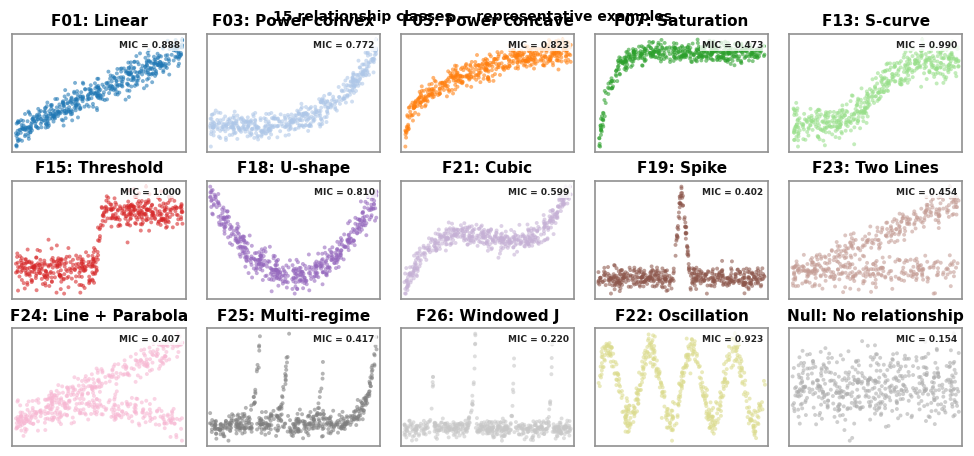

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_labeled_standard_families_snr_grid_rep1.png


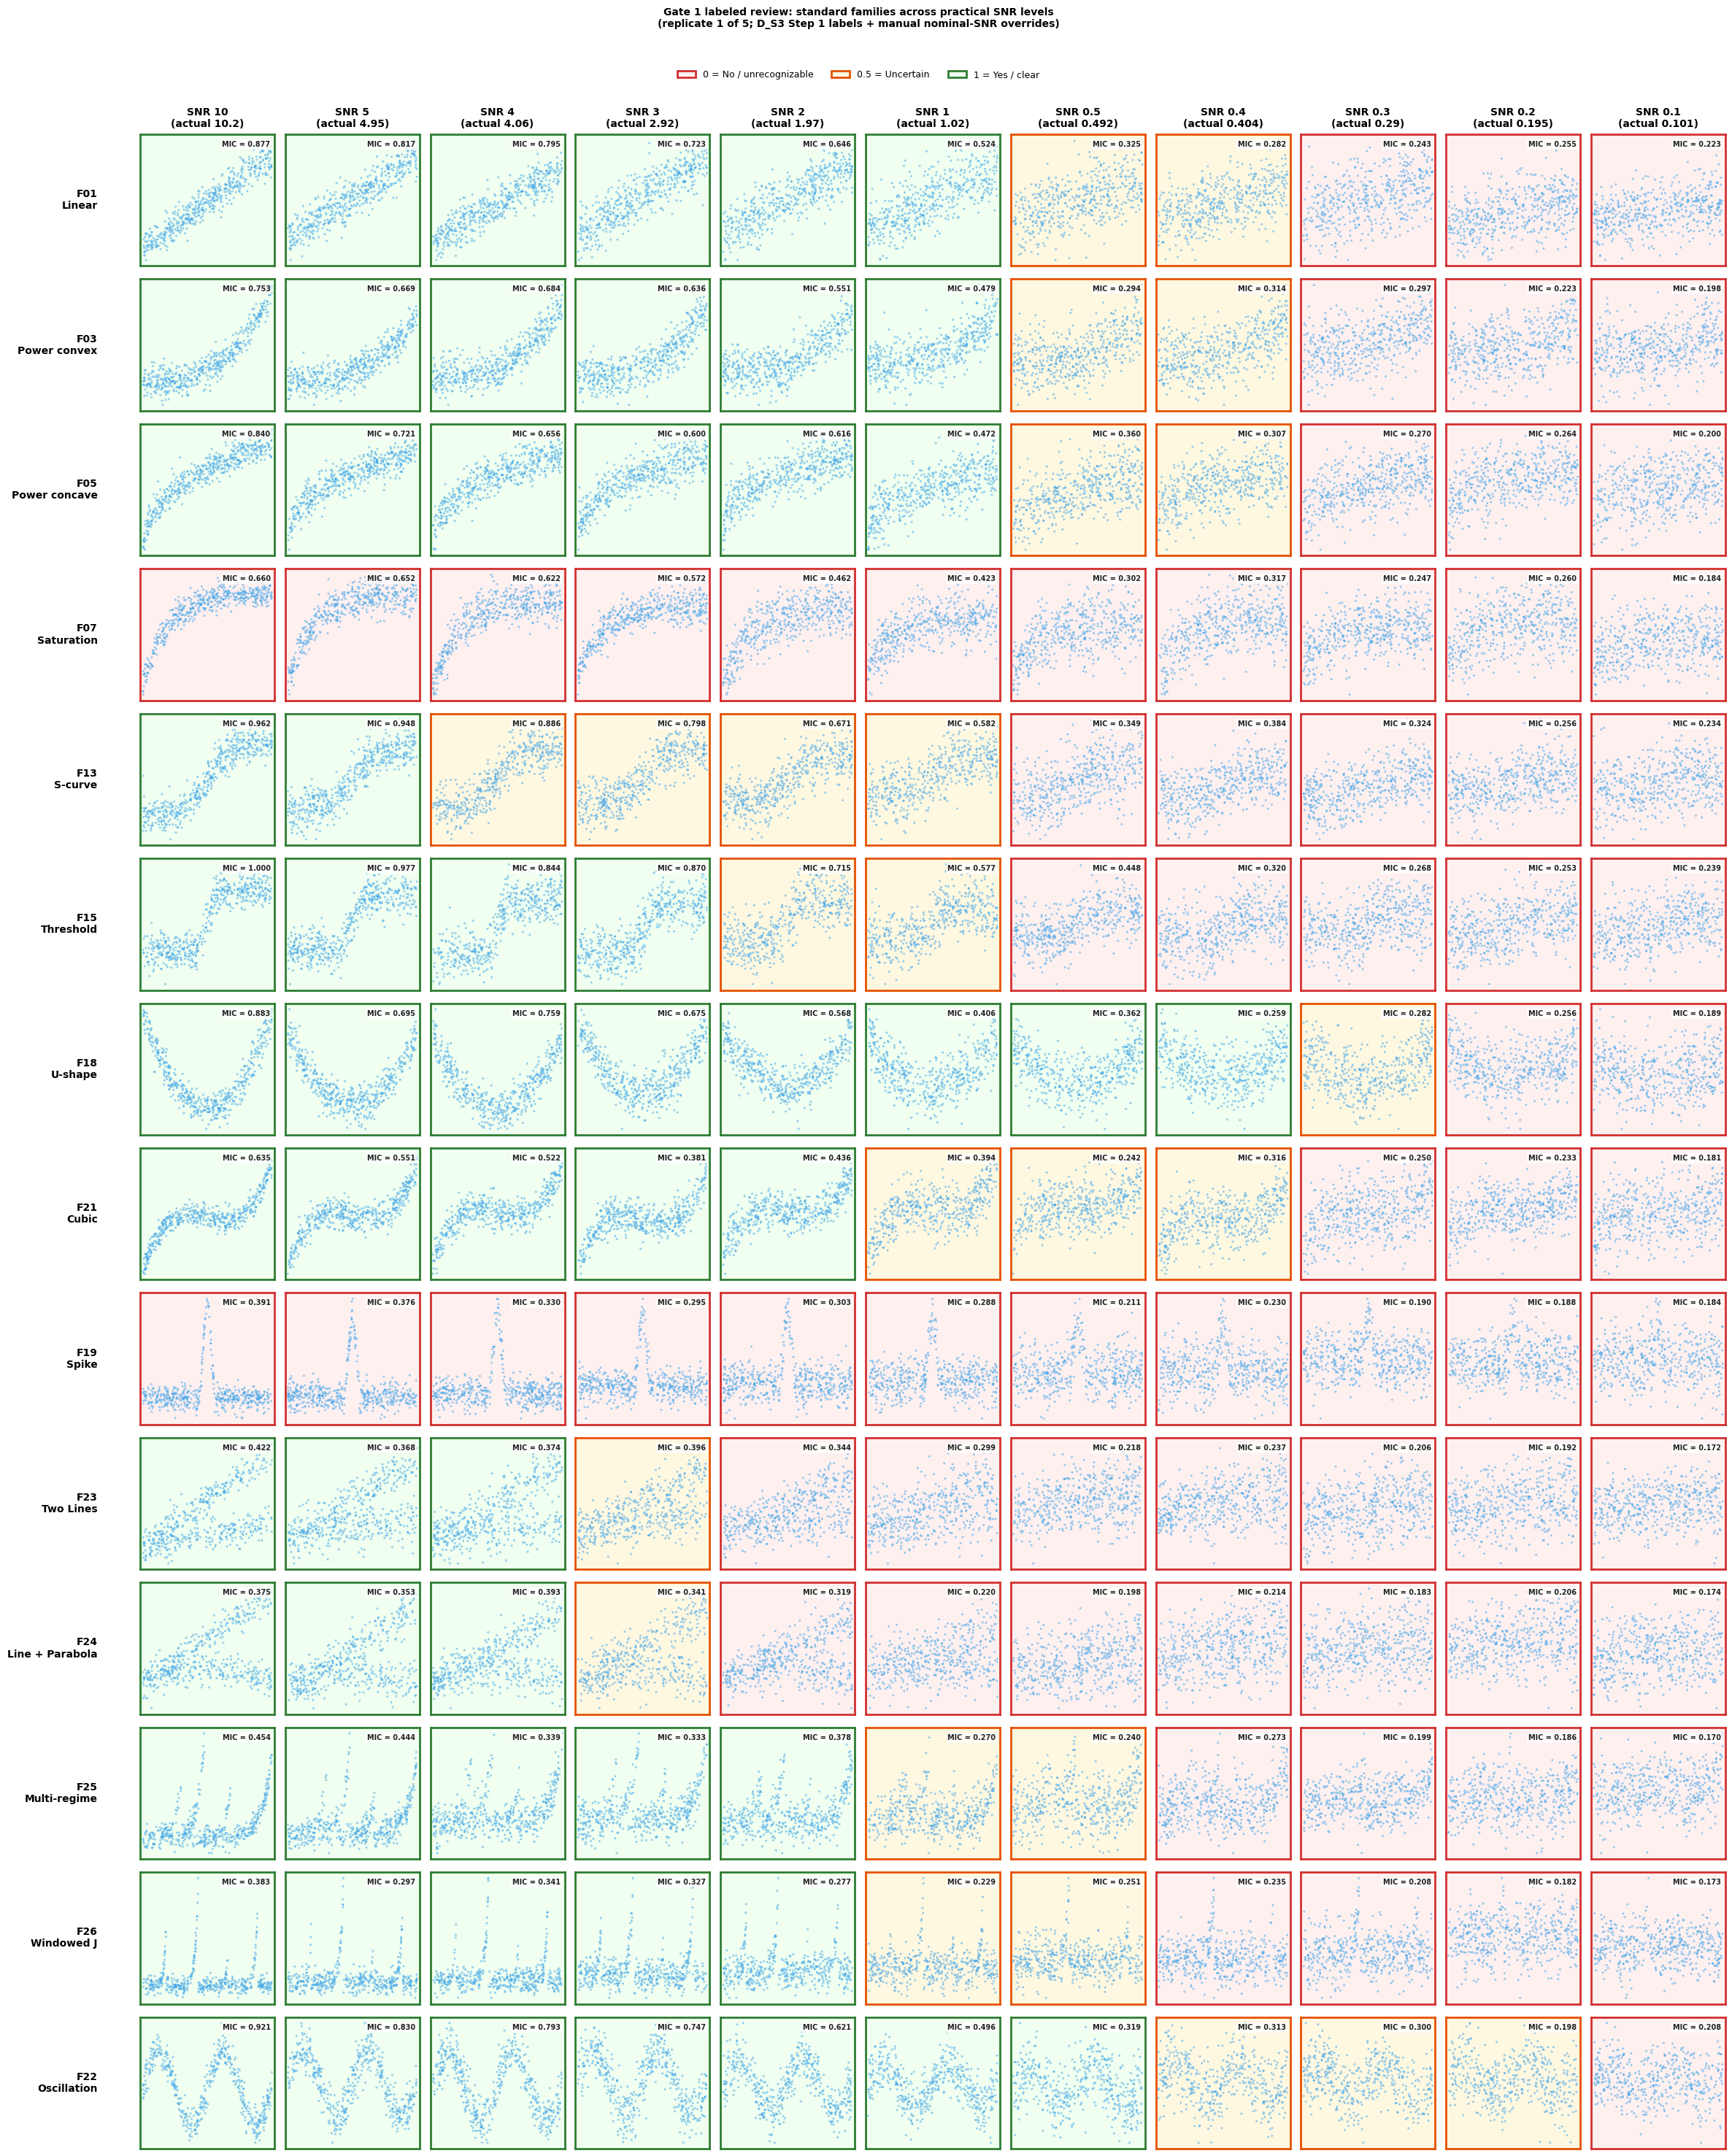

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_labeled_standard_families_snr_grid_rep2.png


KeyboardInterrupt: 

In [7]:
array_indices = selection['array_index'].to_numpy(dtype=int)

# scatter_points.npz is compressed, so the two arrays are decompressed in turn
# and immediately reduced to the selected signal cases.
with np.load(points_path) as points:
    x_selected = points['x'][array_indices].copy()
    y_selected = points['y'][array_indices].copy()

# Compact 15-class overview: 14 signal families from one enabled level + one Null.
overview_variant_level = (
    'strong' if 'strong' in selected_variant_levels else selected_variant_levels[-1]
)
overview_null_rng = np.random.default_rng(20260720)
overview_x_null = overview_null_rng.uniform(0.0, 1.0, 500).astype(np.float32)
overview_y_null = overview_null_rng.normal(0.0, 1.0, 500).astype(np.float32)
overview_null_mic = compute_mic(overview_x_null, overview_y_null)

overview_items = []
for family_id, short_name in selected_families:
    record = selection[
        selection['family_id'].eq(family_id)
        & selection['variant_level'].eq(overview_variant_level)
        & selection['nominal_snr'].eq(10.0)
        & selection['replicate'].eq(0)
    ]
    if len(record) != 1:
        raise ValueError(f'Expected one overview record for {family_id}; found {len(record)}')
    pos = int(record.iloc[0]['loaded_position'])
    overview_items.append((
        family_id, short_name, x_selected[pos], y_selected[pos], float(record.iloc[0]['MIC'])
    ))

overview_items.append(('Null', 'No relationship', overview_x_null, overview_y_null, overview_null_mic))
assert len(overview_items) == 15

overview_colors = plt.cm.tab20(np.linspace(0.02, 0.92, len(overview_items)))
overview_colors[-1] = np.array([0.68, 0.68, 0.68, 1.0])

overview_fig, overview_axes = plt.subplots(3, 5, figsize=(10, 4.5), squeeze=False)
for idx, (family_id, short_name, x_values, y_values, mic_value) in enumerate(overview_items):
    ax = overview_axes.flat[idx]
    ax.scatter(
        x_values,
        y_values,
        s=8,
        alpha=0.58,
        color=overview_colors[idx],
        edgecolors='none',
        rasterized=True,
    )
    annotate_mic(ax, mic_value, fontsize=6.5)
    ax.set_xlim(-0.02, 1.02)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{family_id}: {short_name}', fontsize=11, fontweight='bold', pad=6)
    for spine in ax.spines.values():
        spine.set_color('#909090')
        spine.set_linewidth(1.2)

# overview_fig.suptitle(
#     '15 relationship classes — representative examples\n',
#     # f'(signal: {overview_variant_level}, nominal SNR 10, replicate 1; Null: independent control)',
#     fontsize=10,
#     fontweight='bold',
#     y=0.995,
# )
overview_fig.subplots_adjust(left=0.04, right=0.99, bottom=0.025, top=0.94, wspace=0.12, hspace=0.25)

overview_figure_path = output_dir / 'gate1_15_relationship_classes_overview_5x3.png'
overview_fig.savefig(overview_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
print(f'Saved: {overview_figure_path}')
plt.show()

nrows = len(selected_families)
ncols = len(nominal_snr)

signal_figure_paths = []

for preview_variant_level in selected_variant_levels:
    for preview_replicate in selected_replicates:
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(24, 30),
            squeeze=False,
        )

        for row_idx, (family_id, short_name) in enumerate(selected_families):
            for col_idx, (nominal, actual) in enumerate(zip(nominal_snr, actual_snr)):
                record = selection[
                    selection['family_id'].eq(family_id)
                    & selection['variant_level'].eq(preview_variant_level)
                    & selection['nominal_snr'].eq(float(nominal))
                    & selection['replicate'].eq(preview_replicate)
                ]
                if len(record) != 1:
                    raise ValueError(
                        f'Expected one loaded record for {family_id}, level={preview_variant_level}, '
                        f'SNR={nominal}, rep={preview_replicate}'
                    )
                pos = int(record.iloc[0]['loaded_position'])
                label_value = float(record.iloc[0]['label'])
                label_style = label_styles[label_value]
                ax = axes[row_idx, col_idx]
                ax.scatter(
                    x_selected[pos],
                    y_selected[pos],
                    s=5,
                    alpha=0.52,
                    color='#42A5E8',
                    edgecolors='none',
                    rasterized=True,
                )
                annotate_mic(ax, float(record.iloc[0]['MIC']), fontsize=7)
                ax.set_xlim(-0.02, 1.02)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_facecolor(label_style['face'])
                for spine in ax.spines.values():
                    spine.set_color(label_style['edge'])
                    spine.set_linewidth(2.0)

                if row_idx == 0:
                    ax.set_title(
                        f'SNR {nominal:g}\n(actual {actual:.3g})',
                        fontsize=10,
                        fontweight='bold',
                        pad=7,
                    )

                if col_idx == 0:
                    ax.set_ylabel(
                        f'{family_id}\n{short_name}',
                        fontsize=10,
                        fontweight='bold',
                        rotation=0,
                        ha='right',
                        va='center',
                        labelpad=42,
                    )

        fig.suptitle(
            f'Gate 1 labeled review: {preview_variant_level} families across practical SNR levels\n'
            f'(replicate {preview_replicate + 1} of {len(selected_replicates)}; '
            'D_S3 Step 1 labels + manual nominal-SNR overrides)',
            fontsize=10,
            fontweight='bold',
            y=0.998,
        )
        fig.legend(
            handles=label_legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.5, 0.973),
            ncol=3,
            frameon=False,
            fontsize=9,
        )
        fig.subplots_adjust(left=0.09, right=0.995, bottom=0.02, top=0.94, wspace=0.08, hspace=0.10)

        signal_figure_path = output_dir / (
            f'gate1_labeled_{preview_variant_level}_families_snr_grid_rep{preview_replicate + 1}.png'
        )
        fig.savefig(signal_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
        signal_figure_paths.append(signal_figure_path)
        print(f'Saved: {signal_figure_path}')
        if preview_replicate == selected_replicates[0]:
            plt.show()
        else:
            plt.close(fig)

# Focused, label-neutral review grid for the supplemental F23/F24 SNR 4 cases.
supplemental_selection = selection[selection['is_supplemental']].copy()
supplemental_figure_path = None
if not supplemental_selection.empty:
    supplemental_row_specs = [
        (family_id, variant_level)
        for family_id in supplemental_snr_by_family
        for variant_level in ['standard', 'strong']
        if variant_level in selected_variant_levels
    ]
    fig, axes = plt.subplots(
        len(supplemental_row_specs), len(selected_replicates),
        figsize=(12, 8), squeeze=False,
    )

    for row_idx, (family_id, variant_level) in enumerate(supplemental_row_specs):
        short_name = dict(selected_families)[family_id]
        for col_idx, replicate in enumerate(selected_replicates):
            record = supplemental_selection[
                supplemental_selection['family_id'].eq(family_id)
                & supplemental_selection['variant_level'].eq(variant_level)
                & supplemental_selection['nominal_snr'].eq(4.0)
                & supplemental_selection['replicate'].eq(replicate)
            ]
            if len(record) != 1:
                raise ValueError(
                    f'Expected one supplemental case for {family_id}, {variant_level}, '
                    f'rep={replicate}; found {len(record)}'
                )
            pos = int(record.iloc[0]['loaded_position'])
            ax = axes[row_idx, col_idx]
            ax.scatter(
                x_selected[pos], y_selected[pos], s=6, alpha=0.55,
                color='#42A5E8', edgecolors='none', rasterized=True,
            )
            annotate_mic(ax, float(record.iloc[0]['MIC']), fontsize=7)
            ax.set_xlim(-0.02, 1.02)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor('#F7F7F7')
            for spine in ax.spines.values():
                spine.set_color('#6D6D6D')
                spine.set_linewidth(1.8)
            if row_idx == 0:
                ax.set_title(f'Repeat {replicate + 1}', fontsize=10, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(
                    f'{family_id} {short_name}\n{variant_level.title()}',
                    fontsize=9, fontweight='bold', rotation=0,
                    ha='right', va='center', labelpad=48,
                )

    supplemental_actual = supplemental_selection['actual_snr'].iloc[0]
    fig.suptitle(
        'Focused boundary review: F23/F24 at nominal SNR 4 '
        f'(actual {supplemental_actual:.3g})\n'
        'Standard and Strong × 5 repeats — label pending manual review',
        fontsize=12, fontweight='bold', y=0.995,
    )
    fig.subplots_adjust(left=0.18, right=0.99, bottom=0.04, top=0.91, wspace=0.10, hspace=0.14)
    supplemental_figure_path = output_dir / 'gate1_supplemental_f23_f24_snr4_review.png'
    fig.savefig(supplemental_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
    print(f'Saved: {supplemental_figure_path}')
    plt.show()


## Null candidate set — 100 independent realizations, not SNR columns

For Null, `x` and `y` are generated independently. Changing the marginal variance of `y` does not create a meaningful signal-to-noise ratio, so 20 independent batches are generated at a fixed distribution, with five independent replicates per batch. For readability, the 100 controls are displayed as two 5 × 10 grids.


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_null_independent_examples_batches_01_10.png


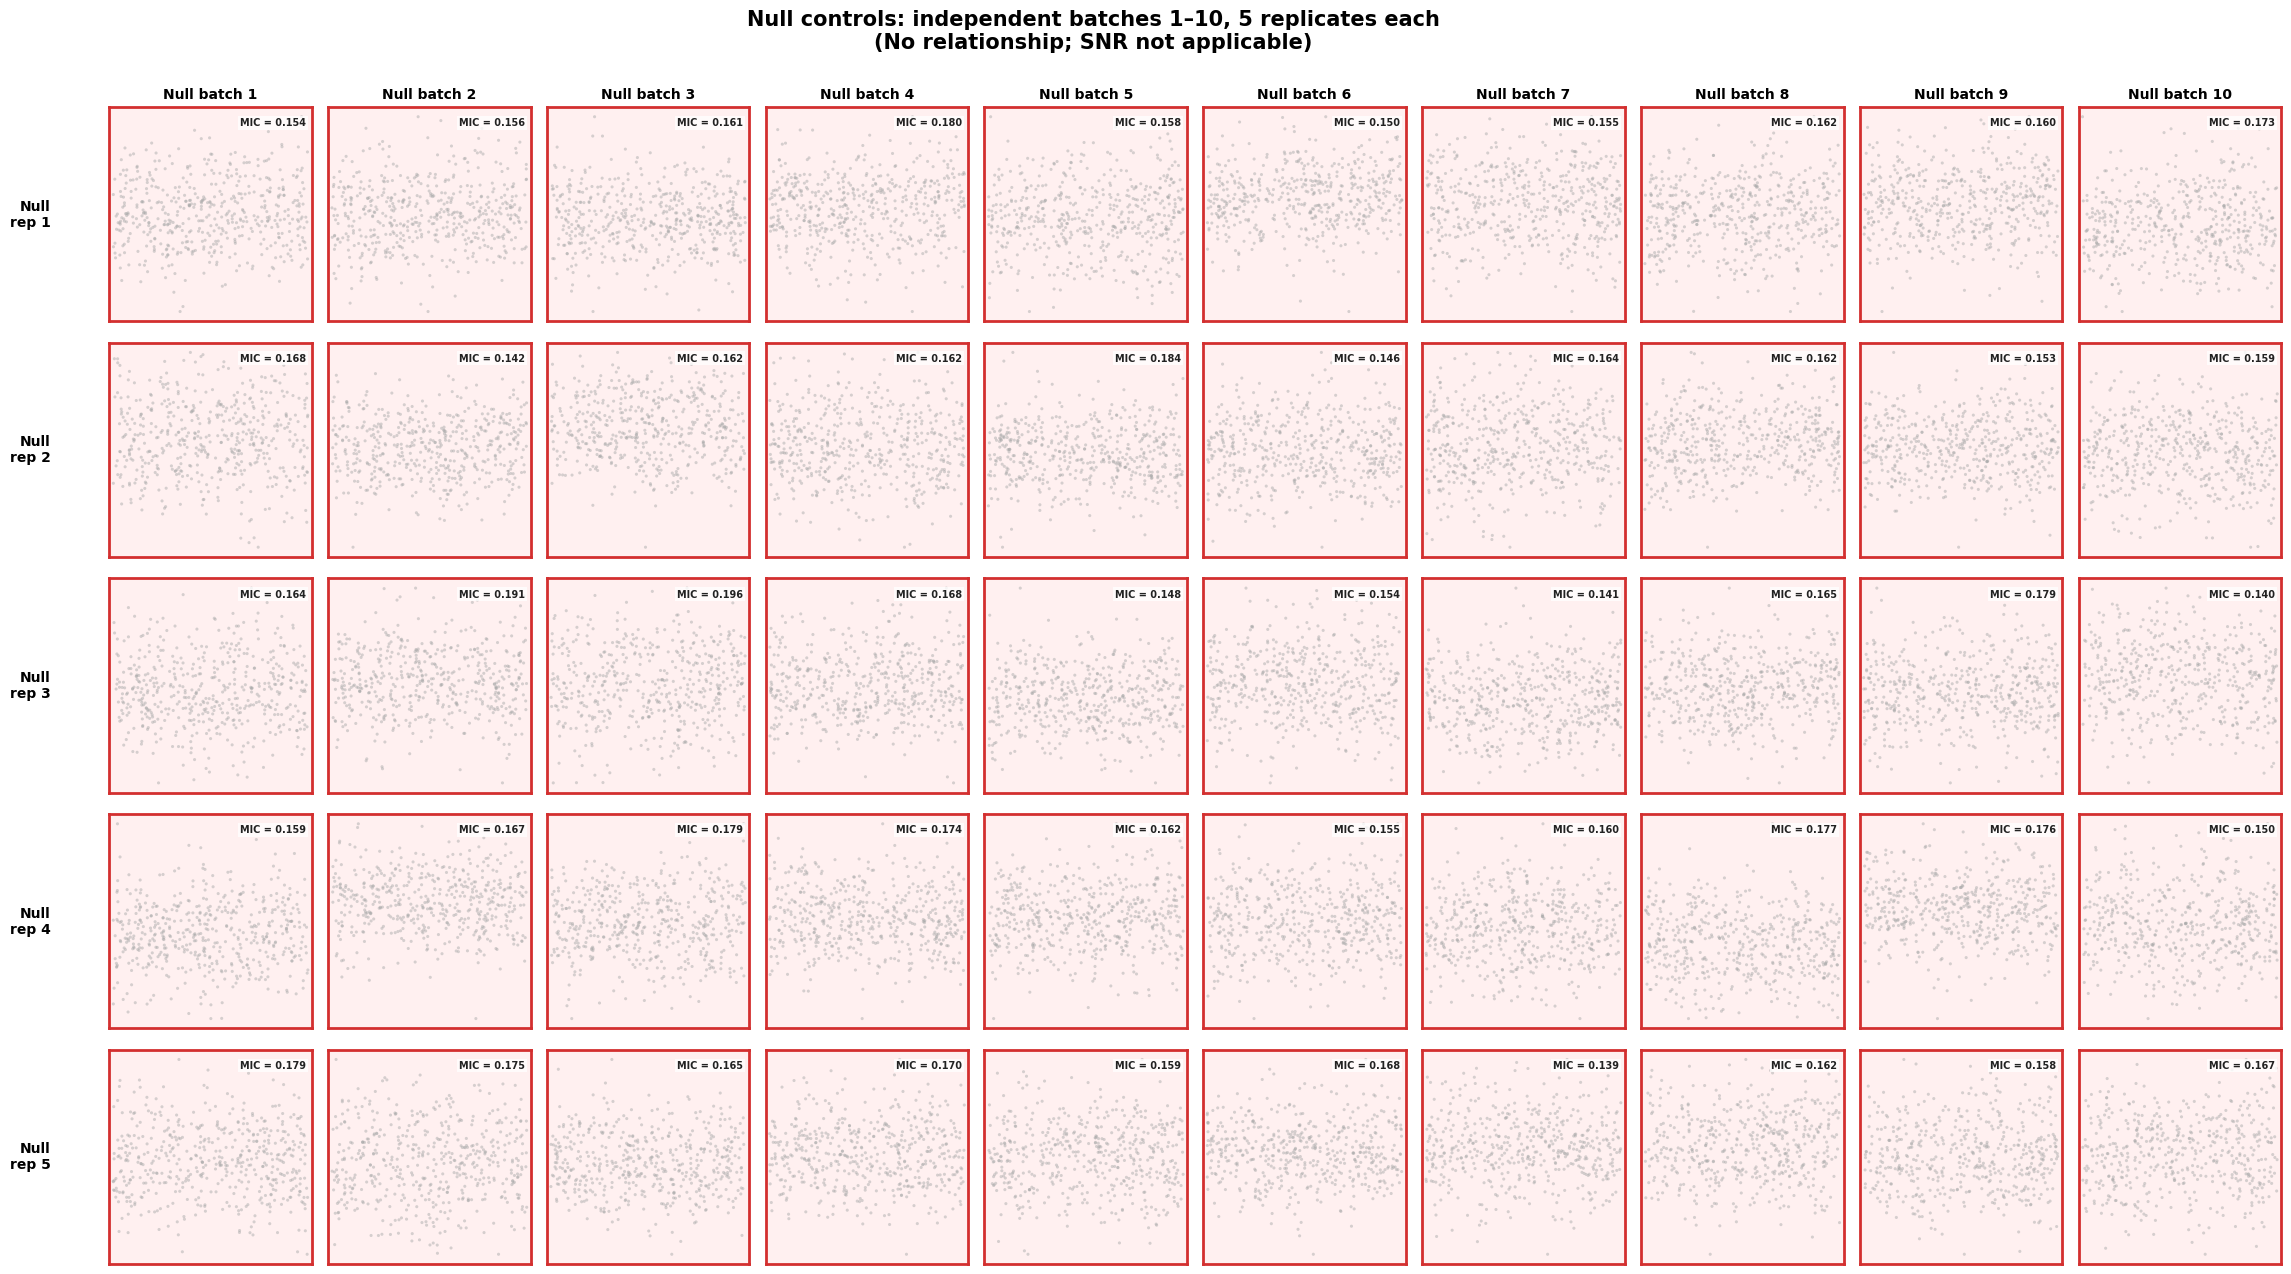

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_null_independent_examples_batches_11_20.png

Unified candidate set
  Signal: 1540
  Null:   100
  Total:  1640
  Manifest: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_candidate_manifest.csv
  Points:   /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S1_gate1_preview/gate1_candidate_points.npz


plots
family_id variant_level       
F01       standard          55
          strong            55
F03       standard          55
          strong            55
F05       standard          55
          strong            55
F07       standard          55
          strong            55
F13       standard          55
          strong            55
F15       standard          55
          strong            55
F18       standard          55
          strong            55
F19       standard          55
          strong            55
F21       standard          55
          strong            55
F22       standard          55
          strong            55
F23       standard          55
          strong            55
F24       standard          55
          strong            55
F25       standard          55
          strong            55
F26       standard          55
          strong            55
Null      none             100

,plots
label,
0.0,790
0.5,250
1.0,600


In [61]:
n_null_batches = 20
n_points = 500
null_rows = []
null_x_rows = []
null_y_rows = []

for batch in range(n_null_batches):
    for replicate in selected_replicates:
        seed = 20260720 + batch * 100 + replicate
        rng = np.random.default_rng(seed)
        x_null = rng.uniform(0.0, 1.0, n_points).astype(np.float32)
        y_null = rng.normal(0.0, 1.0, n_points).astype(np.float32)
        null_mic = compute_mic(x_null, y_null)
        null_x_rows.append(x_null)
        null_y_rows.append(y_null)
        null_rows.append({
            'plot_id': f'Null_batch_{batch + 1}_rep_{replicate + 1}',
            'family_id': 'Null',
            'family_short_name': 'No relationship',
            'family_name': 'No relationship',
            'variant_name': 'independent_normal',
            'variant_level': 'none',
            'nominal_snr': np.nan,
            'actual_snr': np.nan,
            'replicate': replicate,
            'null_batch': batch + 1,
            'case_id': np.nan,
            'seed': seed,
            'MIC': null_mic,
            'label': 0.0,
            'label_source': label_source_name,
        })

null_manifest = pd.DataFrame(null_rows)
null_manifest['is_supplemental'] = False
null_manifest['review_status'] = 'labeled'
x_null_selected = np.stack(null_x_rows)
y_null_selected = np.stack(null_y_rows)
assert len(null_manifest) == n_null_batches * len(selected_replicates) == 100

null_figure_paths = []
null_batches_per_page = 10

for page_start in range(0, n_null_batches, null_batches_per_page):
    page_batches = list(range(page_start, min(page_start + null_batches_per_page, n_null_batches)))
    fig, axes = plt.subplots(
        len(selected_replicates),
        len(page_batches),
        figsize=(24, 13),
        squeeze=False,
    )

    for page_col, batch in enumerate(page_batches):
        for replicate in selected_replicates:
            pos = batch * len(selected_replicates) + replicate
            ax = axes[replicate, page_col]
            ax.scatter(
                x_null_selected[pos],
                y_null_selected[pos],
                s=5,
                alpha=0.48,
                color='#A9A9A9',
                edgecolors='none',
                rasterized=True,
            )
            annotate_mic(ax, float(null_manifest.iloc[pos]['MIC']), fontsize=7)
            ax.set_xlim(-0.02, 1.02)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_facecolor(label_styles[0.0]['face'])
            if replicate == selected_replicates[0]:
                ax.set_title(f'Null batch {batch + 1}', fontsize=10, fontweight='bold')
            if page_col == 0:
                ax.set_ylabel(
                    f'Null\nrep {replicate + 1}',
                    fontsize=10,
                    fontweight='bold',
                    rotation=0,
                    ha='right',
                    va='center',
                    labelpad=42,
                )
            for spine in ax.spines.values():
                spine.set_color(label_styles[0.0]['edge'])
                spine.set_linewidth(2.0)

    fig.suptitle(
        f'Null controls: independent batches {page_batches[0] + 1}–{page_batches[-1] + 1}, '
        f'{len(selected_replicates)} replicates each\n'
        '(No relationship; SNR not applicable)',
        fontsize=15,
        fontweight='bold',
        y=0.995,
    )
    fig.subplots_adjust(left=0.09, right=0.995, bottom=0.03, top=0.92, wspace=0.08, hspace=0.10)

    null_figure_path = output_dir / (
        f'gate1_null_independent_examples_batches_{page_batches[0] + 1:02d}_{page_batches[-1] + 1:02d}.png'
    )
    fig.savefig(null_figure_path, dpi=180, bbox_inches='tight', facecolor='white')
    null_figure_paths.append(null_figure_path)
    print(f'Saved: {null_figure_path}')
    if page_start == 0:
        plt.show()
    else:
        plt.close(fig)

# Export one unified candidate set: enabled signal levels + 100 Null plots.
signal_manifest = selection.drop(columns=['array_index', 'loaded_position']).copy()
signal_manifest['seed'] = np.nan
signal_manifest['source'] = 'D/output/S1 dense-SNR dataset'
null_manifest['source'] = 'generated independent Null control'

candidate_manifest = pd.concat([signal_manifest, null_manifest], ignore_index=True, sort=False)
candidate_manifest.insert(0, 'candidate_index', np.arange(len(candidate_manifest), dtype=int))

# Explicit tracking columns requested for downstream review.
candidate_manifest['repeat_number'] = candidate_manifest['replicate'].astype(int) + 1
candidate_manifest['repeats_per_family_snr_level'] = len(selected_replicates)
candidate_manifest['noise_level_nominal_snr'] = candidate_manifest['nominal_snr']
candidate_manifest['noise_level_actual_snr'] = candidate_manifest['actual_snr']
candidate_manifest['record_id'] = [
    f'S1_case_{int(case_id)}' if pd.notna(case_id) else plot_id
    for case_id, plot_id in zip(candidate_manifest['case_id'], candidate_manifest['plot_id'])
]

candidate_x = np.concatenate([x_selected, x_null_selected], axis=0).astype(np.float32, copy=False)
candidate_y = np.concatenate([y_selected, y_null_selected], axis=0).astype(np.float32, copy=False)

expected_total_count = expected_signal_count + len(null_manifest)
assert len(candidate_manifest) == candidate_x.shape[0] == candidate_y.shape[0] == expected_total_count

manifest_path = output_dir / 'gate1_candidate_manifest.csv'
points_output_path = output_dir / 'gate1_candidate_points.npz'
candidate_manifest.to_csv(manifest_path, index=False)
np.savez_compressed(points_output_path, x=candidate_x, y=candidate_y)

print('\nUnified candidate set')
print(f'  Signal: {len(signal_manifest)}')
print(f'  Null:   {len(null_manifest)}')
print(f'  Total:  {len(candidate_manifest)}')
print(f'  Manifest: {manifest_path}')
print(f'  Points:   {points_output_path}')
display(candidate_manifest.groupby(['family_id', 'variant_level'], dropna=False).size().rename('plots').to_frame())
display(candidate_manifest.groupby('label').size().rename('plots').to_frame())


## Next step

The exported candidate set starts from the Step-1 labels in `D_S3_fuzzy_calibration.ipynb` and then applies the explicit family × nominal-SNR overrides recorded in this notebook. No-global families and Null remain 0. Family, variant, repeat number, nominal/actual SNR, source case ID, and a universal record ID are also retained.
